# Log Odds Ratio Test Plots

Generates log odds ratio test plots found in [Fig. 5](figures/figure_5) and the [Supplementary Figures](figures/supplementary)

## Notebook Workflow

1. Load stage-05 odds-ratio result pickle files.
2. Generate the main odds-ratio distribution and summary plots.
3. Produce supplementary variants used in figure panels.
4. Save final figure outputs with publication settings.

In [2]:
import sys
import os
import matplotlib.pyplot as plt

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

from odds_ratio_test import PermutationTestResults

ort_results = os.path.join(repo_root, "results", "odds_ratio_test", "Results_Mar25")
figure5 = os.path.join(repo_root, "figures", "figure_5")
supp = os.path.join(repo_root, "figures", "supplementary")

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup


/Users/calvin/anaconda3/envs/orb-selection/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load bootstrap results

In [3]:
loss_results = PermutationTestResults.load_from_pickle(str(ort_results + "/Run1_Loss_LT_50-95_10000x/loss_occ50-95_less.pkl"))
dup_results = PermutationTestResults.load_from_pickle(str(ort_results + "/Run2_Dup_RT_50-max_10000x/duplication_occ50-98_greater.pkl"))

In [11]:
loss_results.ci_av

array([-2.75752318,  2.71833232])

In [14]:
dup_results.ci_av

array([-1.81861149,  1.81192599])

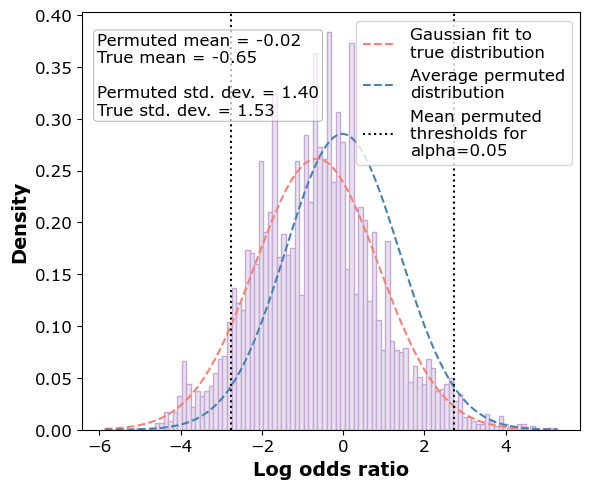

In [15]:
%autoreload 2
loss_results.plot_permutation_results(
    fg_name="orbweavers",
    bg_name="non-orbweavers",
    gaussfit_color="salmon",
    avpermutation_color="steelblue",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    thresholds_color="black",
    title=False,
    legend_fontsize=12,
    textbox_fontsize=12,
    axis_label_fontsize=14
 )

plt.savefig(str(figure5 + "loss_results.png"), dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig(str(ort_results + "Run1_Loss_LT_50-95_10000x/loss_occ50-95_less_permutation_results.png"), dpi=300, bbox_inches="tight")

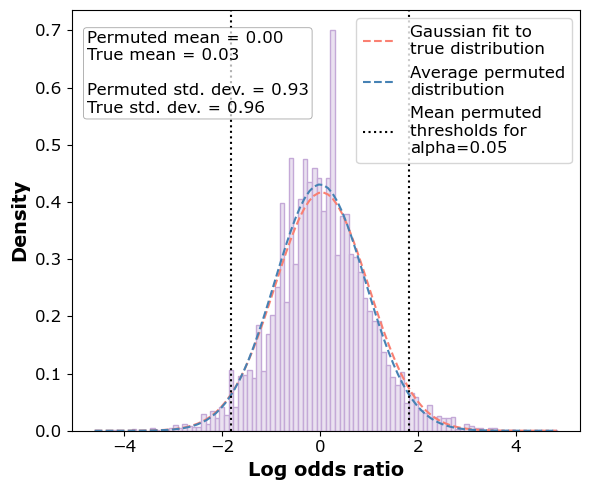

In [12]:
%autoreload 2
dup_results.plot_permutation_results(
    fg_name="orbweavers",
    bg_name="non-orbweavers",
    gaussfit_color="salmon",
    avpermutation_color="steelblue",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    thresholds_color="black",
    title=False,
    legend_fontsize=12,
    textbox_fontsize=12,
    axis_label_fontsize=14
)

plt.savefig(str(figure5 + "dup_results.png"), dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig(str(ort_results + "Run2_Dup_RT_50-max_10000x/dup_occ50-98_greater_permutation_results.png"), dpi=300, bbox_inches="tight")

### For presentations

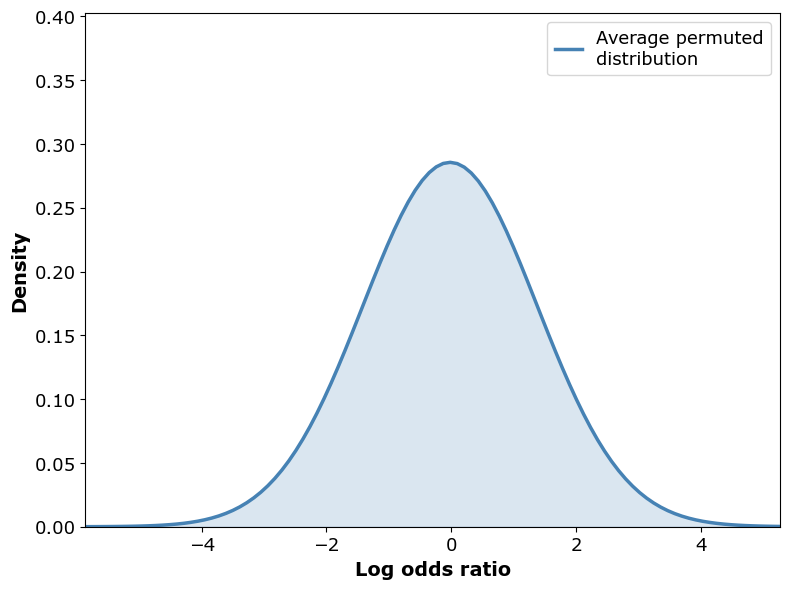

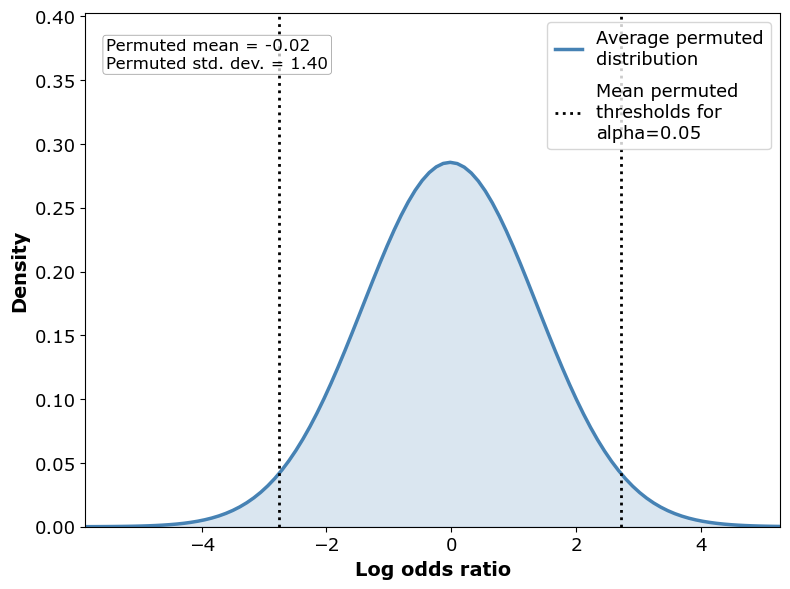

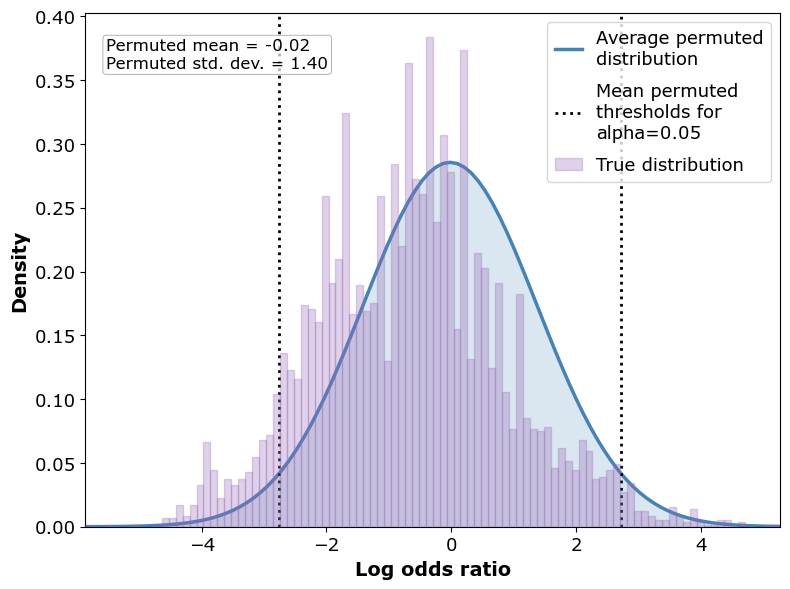

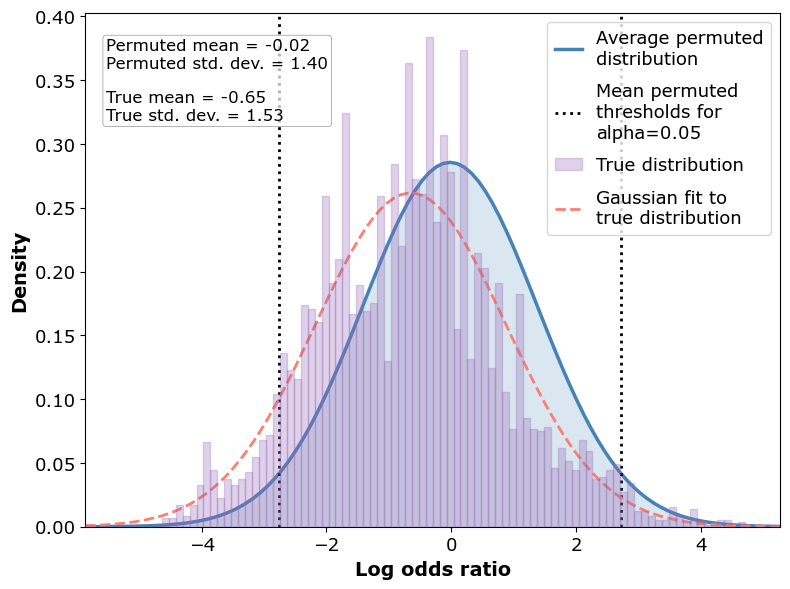

In [15]:
lossfigs, lossaxs = loss_results.plot_permutation_results_layered(
    fg_name="orbweavers",
    bg_name="non-orbweavers",
    gaussfit_color="salmon",
    avpermutation_color="steelblue",
    hist_color="#9569B7",
    thresholds_color="black",
    title=False
)

# for i, fig in enumerate(lossfigs):
#     fig.savefig(str(figure5) + "loss_layered" + str(i) + ".png", dpi=300, bbox_inches="tight", transparent=False)

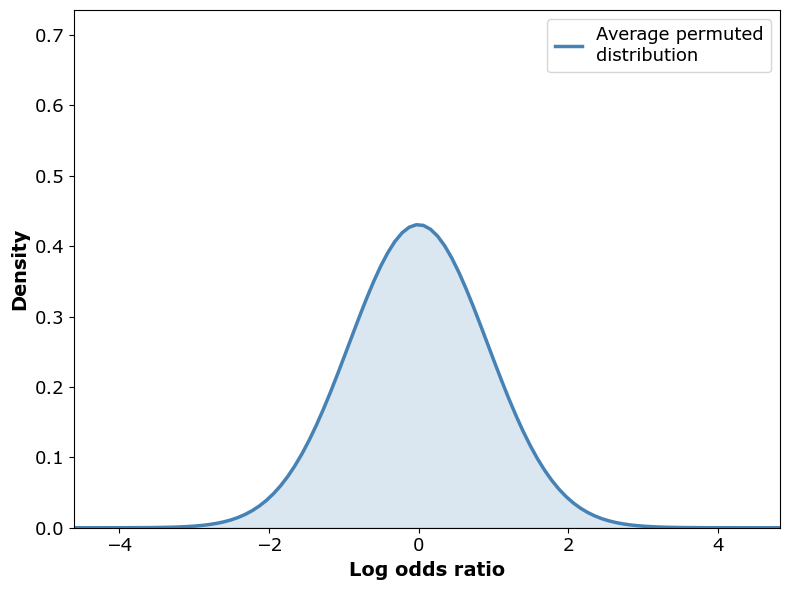

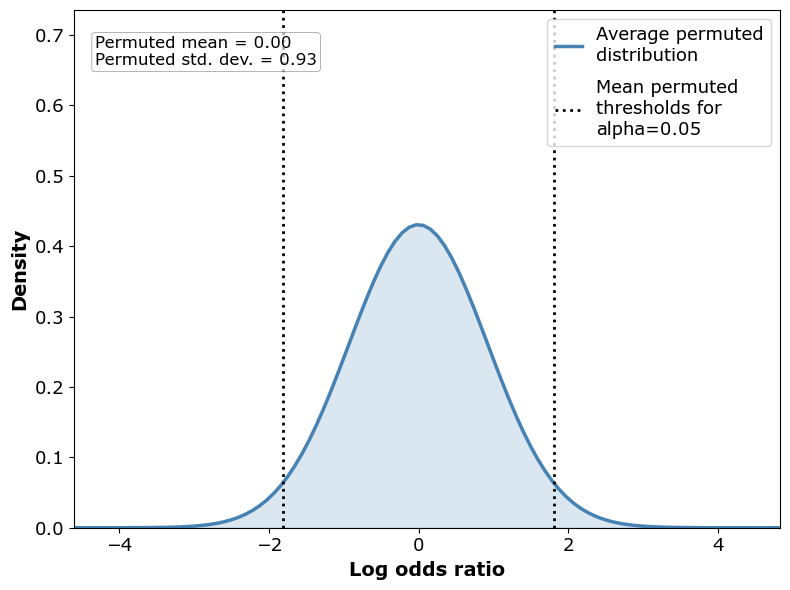

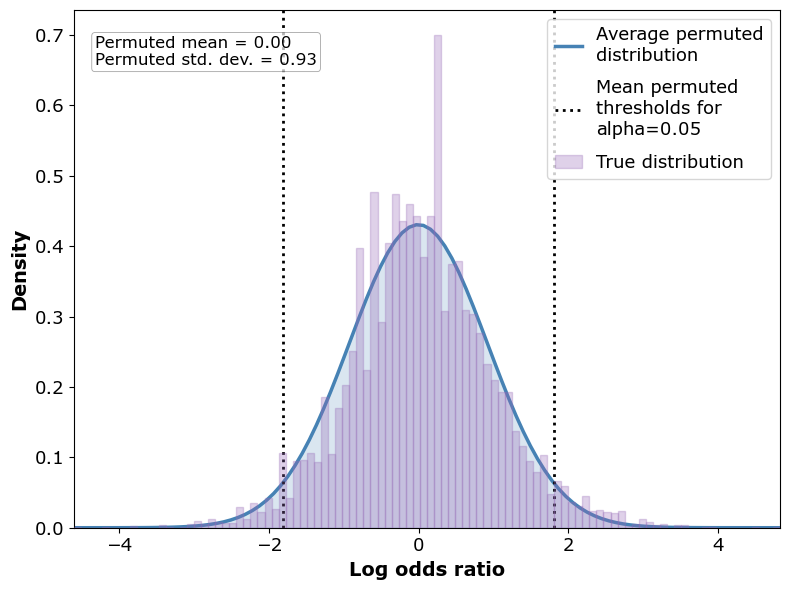

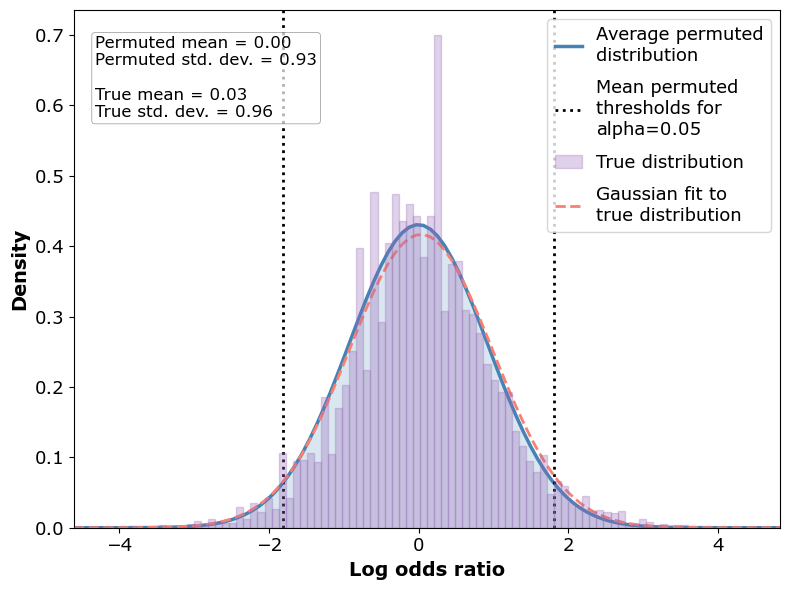

In [16]:
dupfigs, dupaxs = dup_results.plot_permutation_results_layered(
    fg_name="orbweavers",
    bg_name="non-orbweavers",
    gaussfit_color="salmon",
    avpermutation_color="steelblue",
    hist_color="#9569B7",
    thresholds_color="black",
    title=False
)

# for i, fig in enumerate(dupfigs):
#     fig.savefig(str(figure5) + "dup_layered" + str(i) + ".png", dpi=300, bbox_inches="tight", transparent=False)

## Loss permuted stats, all clades included

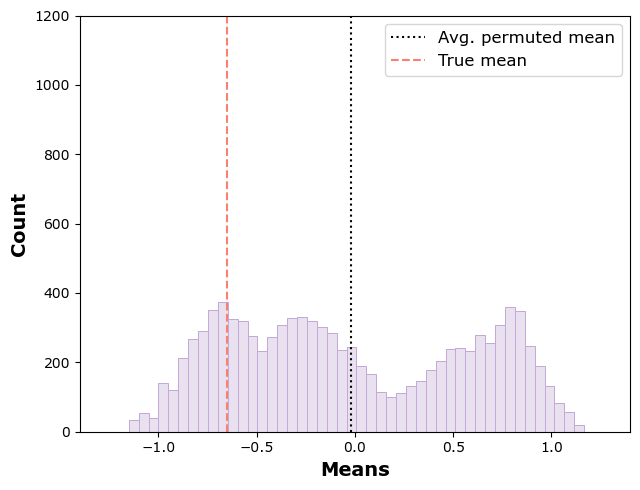

In [93]:
%autoreload 2
loss_results.plot_permutation_stats(
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    ylim=(0, 1200),
    xlim=(-1.4, 1.4),
    binwidth=0.05
 )

plt.savefig(str(figure5 + "/loss_all_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

## Duplication permuted stats, all clades included

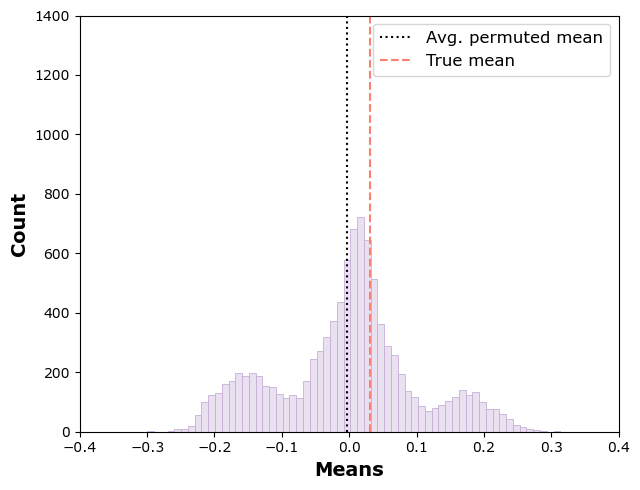

In [94]:

%autoreload 2
dup_results.plot_permutation_stats(
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    ylim=(0, 1400),
    xlim=(-0.4, 0.4),
    binwidth=0.01
 )

plt.savefig(str(figure5 + "/dup_all_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

## Loss permuted stats, no araneids


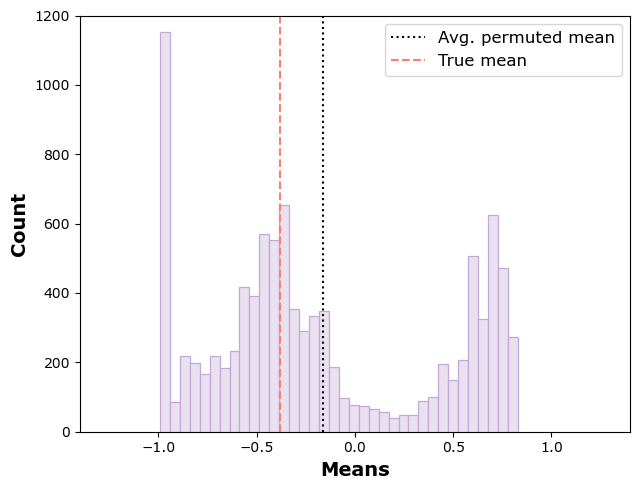

In [95]:
%autoreload 2
ort_dir = os.path.join(repo_root, "results/odds_ratio_test/Results_Apr07")

no_ara_loss_results = PermutationTestResults.load_from_pickle(f'{ort_dir}/Run1_Loss_LT_34-65_10000x/loss_occ34-65_less.pkl')
no_ara_loss_results.plot_permutation_stats(
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    ylim=(0, 1200),
    xlim=(-1.4, 1.4),
 )

plt.savefig(str(figure5 + "/loss_no_ara_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

In [30]:
import numpy as np

arr = no_ara_loss_results.means
values, counts = np.unique(arr, return_counts=True)
repeated = values[counts > 1]
repeated_counts = counts[counts > 1]

for value, count in zip(repeated[:4], repeated_counts[:4]):
    print(value, count)

-0.9922145879205336 3
-0.9608715573126697 2
-0.9480714015007099 1139
-0.9465741058655901 2


In this run with no Araneids, there is one permulated tree that appears many times

In [33]:
from collections import Counter

lst = no_ara_loss_results.permulation_tip_values  # list of dicts

keys = [tuple(sorted(d.items())) for d in lst]  # hashable canonical form
counts = Counter(keys)

any_identical = any(c > 1 for c in counts.values())
print("Any identical dictionaries?", any_identical)

# Show duplicates and how many times they occur
dupes = [(k, c) for k, c in counts.items() if c > 1]
print("Number of duplicated dictionary patterns:", len(dupes))
print("Counts of duplicated patterns:", [c for _, c in dupes])

Any identical dictionaries? True
Number of duplicated dictionary patterns: 727
Counts of duplicated patterns: [13, 3, 107, 16, 21, 22, 3, 115, 1139, 5, 15, 15, 2, 112, 3, 2, 38, 3, 9, 3, 3, 3, 8, 3, 67, 32, 9, 64, 4, 18, 5, 19, 23, 85, 2, 3, 5, 23, 2, 2, 3, 4, 2, 23, 14, 2, 19, 2, 2, 13, 3, 2, 99, 15, 6, 28, 2, 22, 2, 88, 2, 2, 8, 3, 96, 7, 15, 72, 6, 2, 25, 6, 2, 2, 42, 4, 2, 2, 2, 2, 2, 4, 102, 31, 2, 5, 13, 13, 19, 2, 28, 25, 2, 29, 2, 2, 3, 31, 53, 2, 3, 4, 3, 4, 20, 10, 8, 2, 27, 10, 2, 3, 2, 2, 3, 2, 3, 2, 5, 23, 5, 2, 2, 2, 4, 32, 2, 2, 3, 2, 2, 2, 2, 2, 19, 3, 3, 2, 32, 3, 3, 17, 2, 5, 6, 2, 3, 2, 9, 2, 13, 4, 3, 67, 2, 2, 3, 2, 4, 6, 3, 2, 2, 37, 2, 3, 2, 3, 5, 2, 3, 7, 2, 2, 20, 2, 22, 4, 2, 6, 3, 3, 6, 2, 2, 2, 2, 4, 5, 2, 2, 23, 3, 14, 5, 30, 2, 2, 7, 2, 3, 5, 4, 3, 4, 2, 10, 2, 2, 8, 4, 2, 2, 5, 3, 2, 5, 7, 3, 2, 3, 10, 7, 2, 2, 9, 4, 2, 4, 2, 29, 3, 22, 4, 4, 3, 2, 3, 3, 7, 2, 4, 3, 2, 2, 2, 2, 5, 2, 3, 2, 2, 2, 3, 2, 6, 2, 5, 8, 14, 2, 3, 2, 13, 2, 5, 2, 4, 2, 15, 4, 4, 

## Duplication permuted stats, no araneids


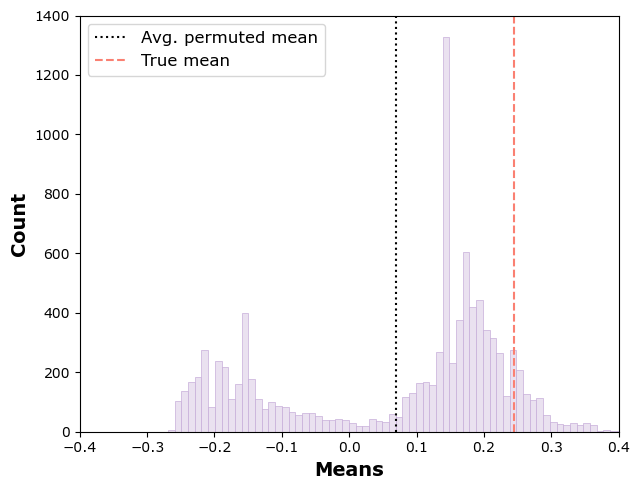

In [96]:
no_ara_dup_results = PermutationTestResults.load_from_pickle(f'{ort_dir}/Run2_Dup_RT_34-max_10000x/duplication_occ34-68_greater.pkl')
no_ara_dup_results.plot_permutation_stats(
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    ylim=(0, 1400),
    xlim=(-0.4, 0.4),
    binwidth=0.01
 )

plt.savefig(str(figure5 + "/dup_no_ara_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

## Loss permuted stats, no tetragnathids

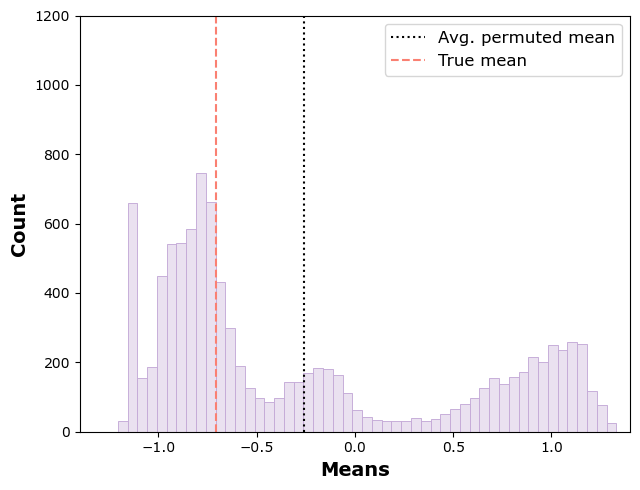

In [97]:
no_tet_loss_results = PermutationTestResults.load_from_pickle(f'{ort_dir}/Run3_Loss_LT_42-81_10000x/loss_occ42-81_less.pkl')
no_tet_loss_results.plot_permutation_stats(
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    ylim=(0, 1200),
    xlim=(-1.4, 1.4)
 )

plt.savefig(str(figure5 + "/loss_no_tet_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

## Duplication permuted stats, no tetragnathids

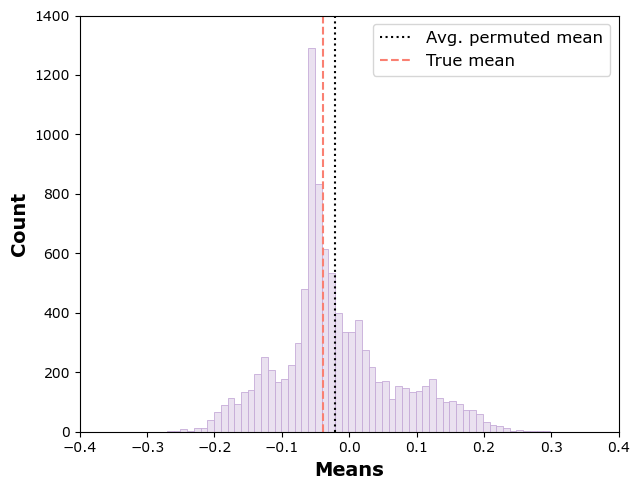

In [98]:
no_tet_dup_results = PermutationTestResults.load_from_pickle(f'{ort_dir}/Run4_Dup_RT_42-max_10000x/duplication_occ42-84_greater.pkl')
no_tet_dup_results.plot_permutation_stats(
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    ylim=(0, 1400),
    xlim=(-0.4, 0.4),
    binwidth=0.01
 )

plt.savefig(str(figure5 + "/dup_no_tet_stats.png"), dpi=300, bbox_inches="tight", transparent=True)